# 생성형 인공지능 — 4주차 실습
## 다른 생성 모델과 관련된 확산 모델 (Diffusion 6장)

강의자료 **그림 6-6 "생성 모델과 확산 모델을 결합하기 위한 5가지 패러다임"** 을 코드로 직접 구현해 봅니다.

| # | 주제 | 강의자료 대응 | 데이터 |
|---|------|--------------|--------|
| 1 | 변분 자동 인코더(VAE)와 ELBO | 그림 6-1, $\mathcal{L}(\phi,\theta;x)$ | 2D 토이 |
| 2 | DDPM = 고정 인코더를 가진 계층적 마르코프 VAE | 노이즈 제거 확산 확률 모델 | 2D 토이 |
| 3 | 적대 신경망(GAN)과 Diffusion-GAN | 그림 6-2, Diffusion-GAN | 2D 토이 |
| 4 | 정규화 흐름과 변수 변환 공식 | 그림 6-3, $x_i=F_i(x_{i-1},\theta)$ | 2D 토이 |
| 5 | 자동 회귀 모델과 Autoregressive Diffusion | 그림 6-4, $\log p(x_{1:T})=\sum_t \log p(x_t \mid x_{<t})$ | MNIST |
| 6 | 에너지 기반 모델과 스코어 | 그림 6-5, $p_\theta(x)=\frac{1}{Z_\theta}\exp(f_\theta(x))$ | 2D 토이 |
| 7 | (종합) 이미지 DDPM + DDIM | 5가지 패러다임 종합 | MNIST |

---

### 실습 방법
* `### 여기에 코드를 작성하세요 ###` 와 `### 여기까지 ###` 사이를 채우면 됩니다. 그 밖의 코드는 수정하지 마세요.
* 각 문제 끝에는 **자동 채점 셀**이 있습니다. `[PASS]` 가 뜨면 정답입니다.
* 맨 마지막 셀에서 `report()` 를 실행하면 전체 채점 결과가 나옵니다.

### 실행 환경
* Colab에서 **런타임 → 런타임 유형 변경 → T4 GPU** 로 바꾸면 훨씬 빠릅니다(없어도 CPU로 전부 실행 가능).
* 예상 소요 시간: CPU 기준 전체 약 10~15분, GPU 기준 약 3분.

> **학생용 노트북입니다.** `raise NotImplementedError(...)` 가 있는 곳을 직접 채우세요. 각 문제 뒤의 채점 셀에서 `[PASS]` 가 모두 뜨면 정답입니다.

## 0. 공통 설정 (반드시 먼저 실행)

In [23]:
import math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def set_seed(s=0):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch', torch.__version__, '| device:', device)

# ---------------- 자동 채점 도구 ----------------
_score = {}

def check(name, cond, msg=''):
    ok = bool(cond)
    _score[name] = ok
    print(('[PASS] ' if ok else '[FAIL] ') + name + ('' if ok else '   -> ' + msg))
    return ok

def report():
    n, k = len(_score), sum(_score.values())
    print('=' * 46)
    print(f'채점 결과: {k} / {n} 통과')
    print('=' * 46)
    for key, v in _score.items():
        print(('  O  ' if v else '  X  ') + key)

torch 2.10.0 | device: cuda


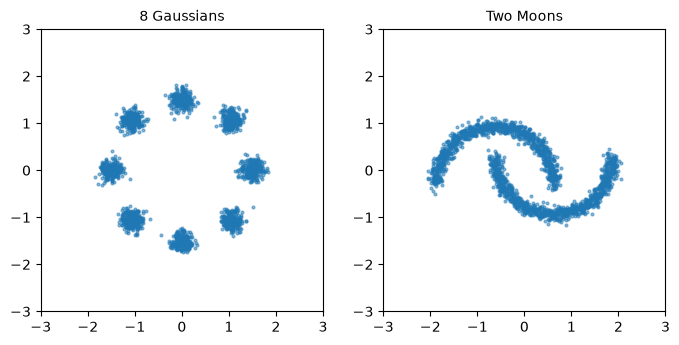

In [24]:
# ---------------- 2D 토이 데이터 ----------------
_ANG = np.arange(8) * 2 * np.pi / 8
EIGHT_CENTERS = np.stack([1.5 * np.cos(_ANG), 1.5 * np.sin(_ANG)], 1).astype(np.float32)

def sample_8gaussians(n, std=0.12):
    idx = np.random.randint(0, 8, n)
    x = EIGHT_CENTERS[idx] + std * np.random.randn(n, 2).astype(np.float32)
    return torch.from_numpy(x)

def sample_moons(n, noise=0.06):
    from sklearn.datasets import make_moons
    x, _ = make_moons(n_samples=n, noise=noise)
    x = (x - np.array([0.5, 0.25])) / 0.8
    return torch.tensor(x, dtype=torch.float32)

def scatter2d(ax, x, title='', color='C0', lim=3.0, s=4):
    x = x.detach().cpu().numpy()
    ax.scatter(x[:, 0], x[:, 1], s=s, alpha=0.5, c=color)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_aspect('equal'); ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
scatter2d(axes[0], sample_8gaussians(2000), '8 Gaussians')
scatter2d(axes[1], sample_moons(2000), 'Two Moons')
plt.tight_layout(); plt.show()

---
# 문제 1. 변분 자동 인코더(VAE)와 증거 하한(ELBO)

강의자료의 식은 다음과 같습니다.

$$\mathcal{L}(\phi,\theta;x)=\mathbb{E}_{q_\phi(z|x)}\big[\log p_\theta(x|z)\big]-D_{KL}\big(q_\phi(z|x)\,\|\,p(z)\big)$$

(슬라이드에는 두 번째 항이 축약 표기되어 있지만, 정확히는 사후 근사 $q_\phi(z|x)$ 와 사전 분포 $p(z)=\mathcal{N}(0,I)$ 사이의 **KL 발산**입니다.)

우리는 이 ELBO 를 **최대화**하는 대신 `-ELBO` 를 **최소화**합니다.

구현할 것:
1. **재매개변수화 트릭** $z=\mu+\sigma\odot\epsilon,\ \epsilon\sim\mathcal{N}(0,I)$
2. **KL 닫힌 형태** $D_{KL}=\tfrac{1}{2}\sum_j(\mu_j^2+\sigma_j^2-1-\log\sigma_j^2)$
3. **-ELBO** (디코더는 고정 분산 $\sigma^2$ 를 갖는 가우시안)

> 이 문제가 중요한 이유: **DDPM 은 인코더가 학습되지 않고 고정된(사후 분포가 미리 정해진) 계층적 마르코프 VAE** 입니다. 즉 문제 2의 손실은 여기서 만든 ELBO 의 특수한 경우입니다.

In [25]:
class Encoder(nn.Module):
    def __init__(self, x_dim=2, h=128, z_dim=2):
        super().__init__()
        self.body = nn.Sequential(nn.Linear(x_dim, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU())
        self.fc_mu, self.fc_logvar = nn.Linear(h, z_dim), nn.Linear(h, z_dim)
    def forward(self, x):
        h = self.body(x)
        return self.fc_mu(h), self.fc_logvar(h).clamp(-8, 8)

class Decoder(nn.Module):
    def __init__(self, z_dim=2, h=128, x_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(z_dim, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, x_dim))
    def forward(self, z):
        return self.net(z)

In [26]:
def reparameterize(mu, logvar):
    '''재매개변수화 트릭. mu, logvar: (B, z_dim) -> z: (B, z_dim)'''
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mu + std * eps
    return z


def kl_to_standard_normal(mu, logvar):
    '''KL( N(mu, diag(exp(logvar))) || N(0, I) ) 를 샘플별로 반환. -> (B,)'''
    kl = 0.5 * (mu.square() + logvar.exp() - 1.0 - logvar).sum(dim=1)
    return kl


def vae_loss(x, enc, dec, sigma=0.15):
    '''-ELBO 를 반환한다.'''
    mu, logvar = enc(x)
    z = reparameterize(mu, logvar)
    x_rec = dec(z)
    D = x.shape[1]
    nll = 0.5 * (x - x_rec).square().sum(dim=1) / sigma**2
    nll = nll + D * math.log(sigma * math.sqrt(2 * math.pi))
    kl = kl_to_standard_normal(mu, logvar)
    neg_elbo = (nll + kl).mean()
    return neg_elbo, nll.mean().detach(), kl.mean().detach()


In [27]:
# ---------------- 문제 1 채점 ----------------
set_seed(1)
mu0 = torch.zeros(200000, 2); lv0 = torch.zeros(200000, 2)
z0 = reparameterize(mu0, lv0)
check('1-1 재매개변수화: 표준정규 통계량',
      abs(z0.mean().item()) < 0.02 and abs(z0.std().item() - 1.0) < 0.02,
      'mu=0, logvar=0 이면 z ~ N(0,1) 이어야 합니다.')

mu1 = torch.full((200000, 2), 3.0); lv1 = torch.full((200000, 2), math.log(4.0))
z1 = reparameterize(mu1, lv1)
check('1-1 재매개변수화: 평균/표준편차 반영',
      abs(z1.mean().item() - 3.0) < 0.03 and abs(z1.std().item() - 2.0) < 0.03,
      'std = exp(0.5*logvar) 인지 확인하세요.')

m = torch.randn(1, 2, requires_grad=True)
check('1-1 미분 가능(그래디언트 흐름)',
      torch.autograd.grad(reparameterize(m, torch.zeros(1, 2)).sum(), m)[0].abs().sum().item() > 0,
      'mu 에 대한 그래디언트가 흘러야 합니다.')

check('1-2 KL: 표준정규이면 0',
      abs(kl_to_standard_normal(torch.zeros(4, 2), torch.zeros(4, 2)).abs().max().item()) < 1e-6)
# 몬테카를로로 KL 을 독립 추정하여 비교
mu_t, lv_t = torch.tensor([[0.7, -1.2]]), torch.tensor([[math.log(0.5), math.log(2.0)]])
q_dist = torch.distributions.Normal(mu_t, torch.exp(0.5 * lv_t))
p_dist = torch.distributions.Normal(torch.zeros(1, 2), torch.ones(1, 2))
zs = q_dist.sample((400000,)).squeeze(1)
kl_mc = (q_dist.log_prob(zs) - p_dist.log_prob(zs)).sum(1).mean().item()
kl_impl = kl_to_standard_normal(mu_t, lv_t).item()
check('1-2 KL: 몬테카를로 추정치와 일치',
      abs(kl_mc - kl_impl) < 0.02, f'MC={kl_mc:.4f} vs 구현={kl_impl:.4f}')

class _StubEnc(nn.Module):                 # mu=0, logvar=0  -> KL = 0
    def forward(self, x): return torch.zeros(x.shape[0], 2), torch.zeros(x.shape[0], 2)
class _StubDec(nn.Module):                 # 항상 0 을 복원
    def forward(self, z): return torch.zeros(z.shape[0], 2)
_xs = torch.tensor([[1.0, 0.0], [0.0, 2.0]])
_l, _, _ = vae_loss(_xs, _StubEnc(), _StubDec(), sigma=0.5)
_expected = 0.5 * (1.0 + 4.0) / 2 / 0.25 + 2 * math.log(0.5) + math.log(2 * math.pi)
check('1-3 -ELBO 값이 이론값과 일치', abs(_l.item() - _expected) < 1e-4,
      f'기대 {_expected:.5f}, 실제 {_l.item():.5f} (정규화 상수 D*log(sigma*sqrt(2pi)) 를 빠뜨리지 마세요)')

set_seed(0)
_l2, _n2, _k2 = vae_loss(sample_8gaussians(512), Encoder(), Decoder())
check('1-3 -ELBO: 실제 모델에서도 유한/양수', torch.isfinite(_l2) and _l2.item() > 0 and _k2.item() >= 0)

[PASS] 1-1 재매개변수화: 표준정규 통계량
[PASS] 1-1 재매개변수화: 평균/표준편차 반영
[PASS] 1-1 미분 가능(그래디언트 흐름)
[PASS] 1-2 KL: 표준정규이면 0
[PASS] 1-2 KL: 몬테카를로 추정치와 일치
[PASS] 1-3 -ELBO 값이 이론값과 일치
[PASS] 1-3 -ELBO: 실제 모델에서도 유한/양수


True

step  500 | -ELBO    2.395 | NLL   -0.989 | KL  3.385
step 1000 | -ELBO    2.382 | NLL   -0.859 | KL  3.241
step 1500 | -ELBO    2.327 | NLL   -0.748 | KL  3.075
step 2000 | -ELBO    1.899 | NLL   -1.097 | KL  2.996
학습 시간 3.7s


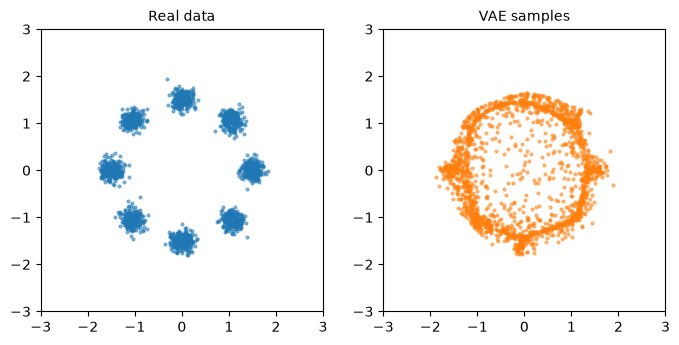

In [28]:
# ---------------- VAE 학습 & 샘플링 ----------------
set_seed(0)
enc, dec = Encoder().to(device), Decoder().to(device)
opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=2e-3)

t0 = time.time()
for step in range(1, 2001):
    x = sample_8gaussians(512).to(device)
    loss, nll, kl = vae_loss(x, enc, dec)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 500 == 0:
        print(f'step {step:4d} | -ELBO {loss.item():8.3f} | NLL {nll.item():8.3f} | KL {kl.item():6.3f}')
print(f'학습 시간 {time.time()-t0:.1f}s')

with torch.no_grad():
    x_gen = dec(torch.randn(2000, 2, device=device)).cpu()
fig, ax = plt.subplots(1, 2, figsize=(7, 3.4))
scatter2d(ax[0], sample_8gaussians(2000), 'Real data')
scatter2d(ax[1], x_gen, 'VAE samples', color='C1')
plt.tight_layout(); plt.show()

---
# 문제 2. DDPM — 고정 인코더를 가진 계층적 마르코프 VAE

강의자료: *"노이즈 제거 확산 확률 모델 : 고정 인코더(사후 분포)를 가진 계층적 마르코프 변분 자동 인코더"*

**순방향(인코더, 학습 파라미터 없음)**
$$q(x_t|x_0)=\mathcal{N}\big(\sqrt{\bar\alpha_t}\,x_0,\ (1-\bar\alpha_t)I\big)
\quad\Longrightarrow\quad x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon$$
여기서 $\alpha_t=1-\beta_t,\ \bar\alpha_t=\prod_{s\le t}\alpha_s$.

**학습 목표(ELBO 를 정리하면 결국 잡음 예측 MSE)**
$$L=\mathbb{E}_{x_0,t,\epsilon}\big\|\epsilon-\epsilon_\theta(x_t,t)\big\|^2$$

**역방향(디코더) 한 스텝**
$$x_{t-1}=\frac{1}{\sqrt{\alpha_t}}\Big(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\Big)+\sqrt{\beta_t}\,z,\quad z\sim\mathcal{N}(0,I)\ (t>1)$$

In [29]:
T = 200
betas  = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
abar   = torch.cumprod(alphas, dim=0)
print('abar[0]=%.5f, abar[-1]=%.5f' % (abar[0].item(), abar[-1].item()))


class SinusoidalEmb(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):                       # t: (B,) long
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device).float() / half)
        ang = t.float()[:, None] * freqs[None, :]
        return torch.cat([ang.sin(), ang.cos()], dim=-1)


class EpsMLP(nn.Module):
    '''2D 데이터용 잡음 예측 네트워크 eps_theta(x, t)'''
    def __init__(self, dim=2, h=128, temb=64):
        super().__init__()
        self.emb = SinusoidalEmb(temb)
        self.tmlp = nn.Sequential(nn.Linear(temb, h), nn.SiLU(), nn.Linear(h, h))
        self.inp = nn.Linear(dim, h)
        self.body = nn.Sequential(nn.SiLU(), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU())
        self.out = nn.Linear(h, dim)
    def forward(self, x, t):
        h = self.inp(x) + self.tmlp(self.emb(t))
        return self.out(self.body(h))

abar[0]=0.99990, abar[-1]=0.13218


In [30]:
def q_sample(x0, t, noise, abar):
    '''순방향 확산: x_t ~ q(x_t | x_0).  x0:(B,D), t:(B,) long, noise:(B,D)'''
    a = abar[t].unsqueeze(-1)
    x_t = a.sqrt() * x0 + (1.0 - a).sqrt() * noise
    return x_t


def ddpm_loss(model, x0, T, abar):
    '''잡음 예측 MSE 손실'''
    B = x0.shape[0]
    t = torch.randint(0, T, (B,), device=x0.device)
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise, abar)
    loss = F.mse_loss(model(x_t, t), noise)
    return loss


@torch.no_grad()
def p_sample_loop(model, n, T, betas, alphas, abar, dim=2, keep=None):
    '''역방향 샘플링. keep 에 지정한 t 들의 중간 결과를 함께 반환.'''
    x = torch.randn(n, dim, device=betas.device)
    traj = {}
    for i in reversed(range(T)):
        t = torch.full((n,), i, device=x.device, dtype=torch.long)
        eps = model(x, t)
        mean = (x - betas[i] / torch.sqrt(1.0 - abar[i]) * eps) / torch.sqrt(alphas[i])
        x = mean + torch.sqrt(betas[i]) * torch.randn_like(x) if i > 0 else mean
        if keep is not None and i in keep:
            traj[i] = x.clone()
    return (x, traj) if keep is not None else x


In [31]:
# ---------------- 문제 2 채점 ----------------
set_seed(2)
x0 = torch.tensor([[3.0, -2.0]], device=device).repeat(40000, 1)
for ti in [0, 50, 199]:
    tt = torch.full((40000,), ti, device=device, dtype=torch.long)
    xt = q_sample(x0, tt, torch.randn_like(x0), abar)
    ok_m = torch.allclose(xt.mean(0), abar[ti].sqrt() * x0[0], atol=0.05)
    ok_v = abs(xt.var(0).mean().item() - (1 - abar[ti]).item()) < 0.05
    check(f'2-1 q_sample t={ti}: 평균/분산', ok_m and ok_v,
          'E[x_t]=sqrt(abar_t)x_0, Var[x_t]=1-abar_t 이어야 합니다.')

class _ZeroModel(nn.Module):
    def forward(self, x, t): return torch.zeros_like(x)
_l = ddpm_loss(_ZeroModel(), sample_8gaussians(20000).to(device), T, abar)
check('2-2 손실: 0을 출력하는 모델이면 E||eps||^2 = 1', abs(_l.item() - 1.0) < 0.05,
      f'기대값 1.0, 실제 {_l.item():.4f} (실제 잡음과의 MSE 인지 확인)')

_s = p_sample_loop(_ZeroModel(), 4000, T, betas, alphas, abar)
check('2-3 샘플러: 출력 형태/유한성', _s.shape == (4000, 2) and torch.isfinite(_s).all())
# eps=0 인 모델이면 역방향 사슬의 분산은 v <- v/alpha_t + beta_t 로 닫힌 형태 계산이 가능하다
_v = torch.tensor(1.0, device=device)
for _i in reversed(range(T)):
    _v = _v / alphas[_i] + (betas[_i] if _i > 0 else 0.0)
check('2-3 샘플러: 역방향 사슬의 분산이 이론값과 일치', abs(_s.var().item() - _v.item()) < 1.2,
      f'기대 {_v.item():.3f}, 실제 {_s.var().item():.3f} (평균 계수와 sqrt(beta_t) 잡음 항을 확인)')

[PASS] 2-1 q_sample t=0: 평균/분산
[PASS] 2-1 q_sample t=50: 평균/분산
[PASS] 2-1 q_sample t=199: 평균/분산
[PASS] 2-2 손실: 0을 출력하는 모델이면 E||eps||^2 = 1
[PASS] 2-3 샘플러: 출력 형태/유한성
[PASS] 2-3 샘플러: 역방향 사슬의 분산이 이론값과 일치


True

step 1000 | loss 0.4672
step 2000 | loss 0.4501
step 3000 | loss 0.4489
step 4000 | loss 0.4795
학습 시간 5.6s


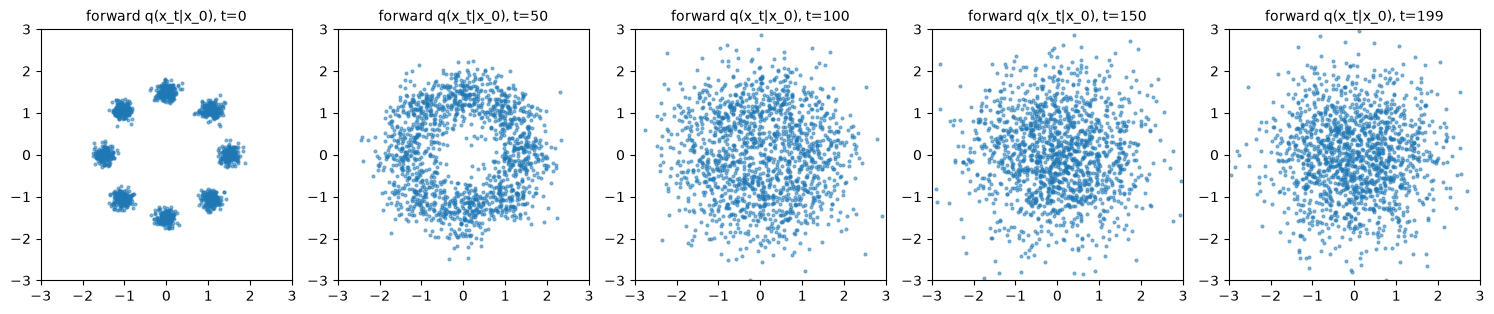

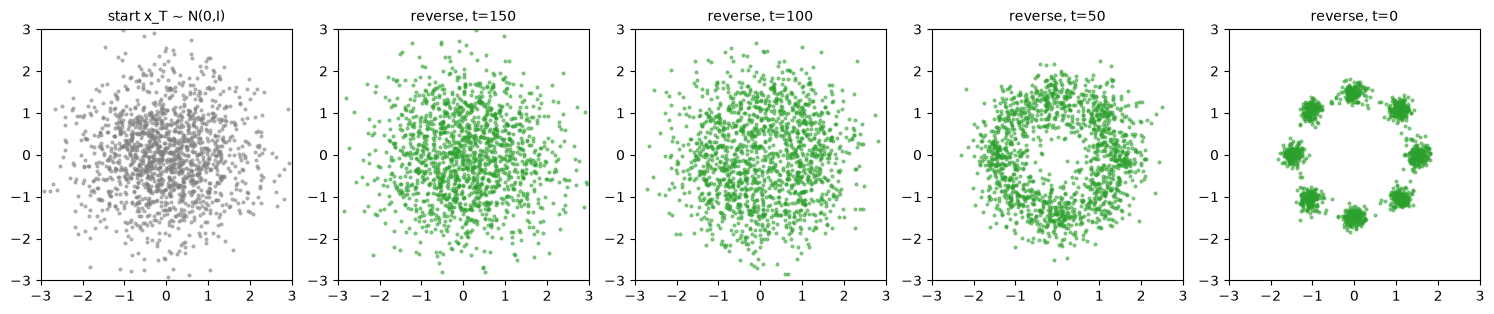

In [32]:
# ---------------- DDPM 학습 & 시각화 ----------------
set_seed(0)
eps_model = EpsMLP().to(device)
opt = torch.optim.Adam(eps_model.parameters(), lr=2e-3)

t0 = time.time()
for step in range(1, 4001):
    x = sample_8gaussians(512).to(device)
    loss = ddpm_loss(eps_model, x, T, abar)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 1000 == 0:
        print(f'step {step:4d} | loss {loss.item():.4f}')
print(f'학습 시간 {time.time()-t0:.1f}s')

# 순방향 확산 과정
fig, ax = plt.subplots(1, 5, figsize=(15, 3.1))
x0v = sample_8gaussians(1500).to(device)
for j, ti in enumerate([0, 50, 100, 150, 199]):
    tt = torch.full((1500,), ti, device=device, dtype=torch.long)
    scatter2d(ax[j], q_sample(x0v, tt, torch.randn_like(x0v), abar).cpu(), f'forward q(x_t|x_0), t={ti}')
plt.tight_layout(); plt.show()

# 역방향 생성 과정
samples, traj = p_sample_loop(eps_model, 1500, T, betas, alphas, abar, keep={150, 100, 50, 0})
fig, ax = plt.subplots(1, 5, figsize=(15, 3.1))
scatter2d(ax[0], torch.randn(1500, 2), 'start x_T ~ N(0,I)', color='C7')
for j, ti in enumerate([150, 100, 50, 0]):
    scatter2d(ax[j + 1], traj[ti].cpu(), f'reverse, t={ti}', color='C2')
plt.tight_layout(); plt.show()

### 생각해 보기 (문제 2)
* VAE(문제 1)의 인코더는 **학습되는** $q_\phi(z|x)$ 였지만, DDPM 의 인코더 $q(x_t|x_{t-1})$ 는 **베타 스케줄로 고정**되어 학습 파라미터가 없습니다.
* 그래서 ELBO 의 KL 항 대부분이 상수가 되고, 남는 것이 위의 **잡음 예측 MSE** 입니다.
* 연속시간 관점(Variational Diffusion Models, Score-Based Diffusion 의 최대 가능도 학습)에서는 이 ELBO 가 **스코어 매칭 목적 함수**와 같아짐이 증명되어 있습니다 → 문제 6에서 다시 봅니다.

---
# 문제 3. 적대 신경망(GAN)과 Diffusion-GAN

강의자료의 목적 함수(그림 6-2):
$$\min_G\max_D\ \mathbb{E}_{x\sim p_{data}}[\log D(x)]+\mathbb{E}_{z\sim\pi}[\log(1-D(G(z)))]$$

실제 코드에서는 수치 안정성을 위해 **로지트(logit)** 를 출력하고 `softplus` 를 씁니다
(강의자료의 *Denoising Diffusion GAN* 코드도 `F.softplus` 를 사용합니다).

$$L_D=\mathbb{E}_{x}\big[\text{softplus}(-D(x))\big]+\mathbb{E}_{z}\big[\text{softplus}(D(G(z)))\big],\qquad
L_G=\mathbb{E}_{z}\big[\text{softplus}(-D(G(z)))\big]$$

($\text{softplus}(u)=\log(1+e^u)$, 그리고 $\text{softplus}(-u)=-\log\sigma(u)$ 이므로 위 식은 표준 비포화(non-saturating) GAN 손실과 같습니다.)

### Diffusion-GAN 아이디어
판별자에게 **깨끗한 샘플 대신 확산으로 잡음을 섞은 샘플**을 보여줍니다.
$$D\big(x_t\big),\quad x_t\sim q(x_t|x),\ t\sim U\{0,\dots,t_{max}-1\}$$
판별자가 지나치게 강해지는 것을 막아 학습을 안정화합니다 — 문제 2에서 만든 `q_sample` 을 그대로 재사용합니다.

In [33]:
class G_net(nn.Module):
    def __init__(self, nz=8, h=128, out=2):
        super().__init__()
        self.nz = nz
        self.net = nn.Sequential(nn.Linear(nz, h), nn.SiLU(), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, out))
    def forward(self, z): return self.net(z)

class D_net(nn.Module):
    def __init__(self, inp=2, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(inp, h), nn.LeakyReLU(0.2),
                                 nn.Linear(h, h), nn.LeakyReLU(0.2), nn.Linear(h, 1))
    def forward(self, x): return self.net(x).view(-1)      # 로지트 (B,)

In [34]:
def d_loss_fn(logit_real, logit_fake):
    '''판별자 손실 (로지트 입력)'''
    loss = F.softplus(-logit_real).mean() + F.softplus(logit_fake).mean()
    return loss


def g_loss_fn(logit_fake):
    '''생성자 손실 (비포화 형태)'''
    loss = F.softplus(-logit_fake).mean()
    return loss


def diffuse_for_D(x, t_max, abar):
    '''Diffusion-GAN: 판별자 입력에 확산 잡음을 주입한다.'''
    B = x.shape[0]
    t = torch.randint(0, t_max, (B,), device=x.device)
    x_t = q_sample(x, t, torch.randn_like(x), abar)
    return x_t


In [35]:
# ---------------- 문제 3 채점 ----------------
z0 = torch.zeros(64)
check('3-1 D 손실: 로지트가 모두 0이면 2*log2', abs(d_loss_fn(z0, z0).item() - 2 * math.log(2)) < 1e-5,
      f'기대 {2*math.log(2):.4f}, 실제 {d_loss_fn(z0, z0).item():.4f}')
check('3-1 D 손실: 완벽한 판별자면 0에 가까움',
      d_loss_fn(torch.full((64,), 20.0), torch.full((64,), -20.0)).item() < 1e-6)
check('3-1 D 손실: 실수한 판별자면 커짐',
      d_loss_fn(torch.full((64,), -5.0), torch.full((64,), 5.0)).item() > 9.0)
check('3-2 G 손실: 로지트 0이면 log2', abs(g_loss_fn(z0).item() - math.log(2)) < 1e-5)
check('3-2 G 손실: 단조 감소(가짜를 진짜로 속일수록 작아짐)',
      g_loss_fn(torch.full((64,), 3.0)).item() < g_loss_fn(torch.full((64,), -3.0)).item())

set_seed(3)
_x = sample_8gaussians(40000).to(device)
_xt = diffuse_for_D(_x, 40, abar)
check('3-3 확산 잡음 주입: 잡음이 실제로 섞임',
      _xt.shape == _x.shape and (_xt - _x).pow(2).mean().item() > 0.005,
      f'평균제곱 변화 {(_xt-_x).pow(2).mean().item():.5f} (q_sample 을 호출했는지 확인)')
_xt2 = diffuse_for_D(_x, T, abar)
check('3-3 확산 잡음 주입: 분산이 N(0,I) 쪽으로 수축',
      _xt2.var(0).mean().item() < _x.var(0).mean().item(),
      '단순히 잡음을 더하면 분산이 커집니다. sqrt(abar_t) 로 축소하는 항도 있어야 합니다.')
_xt1 = diffuse_for_D(_x, 1, abar)
check('3-3 t_max=1 이면 거의 원본 (t=0)', ((_xt1 - _x).abs().mean().item() < 0.02))

[PASS] 3-1 D 손실: 로지트가 모두 0이면 2*log2
[PASS] 3-1 D 손실: 완벽한 판별자면 0에 가까움
[PASS] 3-1 D 손실: 실수한 판별자면 커짐
[PASS] 3-2 G 손실: 로지트 0이면 log2
[PASS] 3-2 G 손실: 단조 감소(가짜를 진짜로 속일수록 작아짐)
[PASS] 3-3 확산 잡음 주입: 잡음이 실제로 섞임
[PASS] 3-3 확산 잡음 주입: 분산이 N(0,I) 쪽으로 수축
[PASS] 3-3 t_max=1 이면 거의 원본 (t=0)


True

학습 시간 16.4s
일반 GAN      : 커버한 모드 8/8  [225, 218, 217, 306, 233, 207, 213, 254]
Diffusion-GAN : 커버한 모드 8/8  [230, 203, 195, 170, 294, 214, 201, 234]


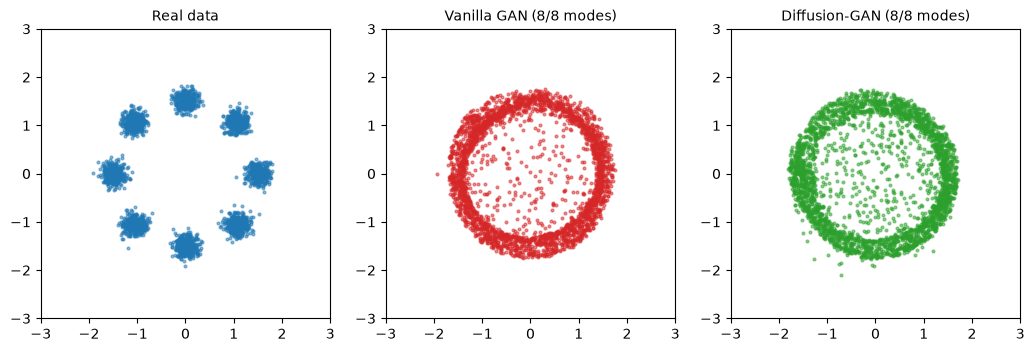

In [36]:
def train_gan(use_diffusion, steps=3000, t_max=60, seed=0):
    set_seed(seed)
    G, D = G_net().to(device), D_net().to(device)
    optG = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.9))
    optD = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.9))
    for step in range(steps):
        x_real = sample_8gaussians(256).to(device)
        x_fake = G(torch.randn(256, G.nz, device=device))
        if use_diffusion:
            xr_in, xf_in = diffuse_for_D(x_real, t_max, abar), diffuse_for_D(x_fake.detach(), t_max, abar)
        else:
            xr_in, xf_in = x_real, x_fake.detach()
        lossD = d_loss_fn(D(xr_in), D(xf_in))
        optD.zero_grad(); lossD.backward(); optD.step()

        x_fake = G(torch.randn(256, G.nz, device=device))
        xf_in = diffuse_for_D(x_fake, t_max, abar) if use_diffusion else x_fake
        lossG = g_loss_fn(D(xf_in))
        optG.zero_grad(); lossG.backward(); optG.step()
    with torch.no_grad():
        return G(torch.randn(3000, G.nz, device=device)).cpu(), lossD.item(), lossG.item()


def mode_coverage(samples, thresh=0.4, min_frac=0.01):
    c = torch.from_numpy(EIGHT_CENTERS)
    d = torch.cdist(samples, c)
    near, idx = d.min(1)
    idx = idx[near < thresh]
    cnt = torch.bincount(idx, minlength=8)
    return int((cnt > min_frac * len(samples)).sum().item()), cnt.tolist()

t0 = time.time()
s_van, *_ = train_gan(False)
s_dif, *_ = train_gan(True)
print(f'학습 시간 {time.time()-t0:.1f}s')
m_van, c_van = mode_coverage(s_van)
m_dif, c_dif = mode_coverage(s_dif)
print(f'일반 GAN      : 커버한 모드 {m_van}/8  {c_van}')
print(f'Diffusion-GAN : 커버한 모드 {m_dif}/8  {c_dif}')

fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.4))
scatter2d(ax[0], sample_8gaussians(3000), 'Real data')
scatter2d(ax[1], s_van, f'Vanilla GAN ({m_van}/8 modes)', color='C3')
scatter2d(ax[2], s_dif, f'Diffusion-GAN ({m_dif}/8 modes)', color='C2')
plt.tight_layout(); plt.show()

### 생각해 보기 (문제 3)
* GAN 은 **샘플링이 빠르지만 모드 붕괴(mode collapse)** 가 잘 일어나고, 확산 모델은 **모드 커버리지가 좋지만 느립니다**.
* *Tackling the Generative Learning Trilemma with Denoising Diffusion GANs* 는 역방향 각 스텝 $p(x_{t-1}|x_t)$ 를 **조건부 GAN** 으로 모델링해, 스텝 수를 수백 → 4 정도로 줄였습니다.
* *Diffusion-GAN* 은 위에서 실험한 것처럼 **판별자 입력에 확산 잡음을 주입**하는 방식입니다.

---
# 문제 4. 정규화 흐름(Normalizing Flow)과 변수 변환 공식

강의자료(그림 6-3): 정규화 흐름은 **다루기 쉬운 분포를 가역 변환의 합성으로 데이터 분포로 바꾸는** 생성 모델입니다.

$$x_i=F_i(x_{i-1},\theta),\qquad x_{i-1}=F_i^{-1}(x_i,\theta),\qquad \forall\,1\le i\le N$$

**변수 변환 공식**으로 로그 우도를 정확히(!) 계산할 수 있습니다. $z=F(x)$ 라 하면

$$\log p_X(x)=\log p_Z\big(F(x)\big)+\log\Big|\det\frac{\partial F(x)}{\partial x}\Big|$$

여기서는 RealNVP 의 **아핀 커플링 층**을 씁니다. 입력을 두 조각 $(x_a,x_b)$ 로 나눈 뒤

$$z_a=x_a,\qquad z_b=x_b\odot e^{s(x_a)}+t(x_a),\qquad \log\Big|\det\frac{\partial z}{\partial x}\Big|=\sum_j s_j(x_a)$$

역변환은 $x_b=(z_b-t(x_a))\,e^{-s(x_a)}$ 로 **닫힌 형태**입니다.

> 확산 모델과의 연결: **DDIM 샘플러(문제 7)** 는 잡음 $x_T$ 를 데이터 $x_0$ 로 보내는 **결정론적·가역 사상**이라서, 정규화 흐름과 같은 역할을 합니다. *Diffusion Normalizing Flow*, *INDM(암시적 비선형 확산 모델)* 이 이 둘을 명시적으로 결합한 연구입니다.

In [37]:
class AffineCoupling(nn.Module):
    def __init__(self, flip=False, h=64):
        super().__init__()
        self.flip = flip
        self.net = nn.Sequential(nn.Linear(1, h), nn.Tanh(), nn.Linear(h, h), nn.Tanh(), nn.Linear(h, 2))
        nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)

    def _st(self, xa):
        s, t = self.net(xa).chunk(2, dim=1)
        return torch.tanh(s) * 2.0, t

    def _split(self, x):
        return (x[:, :1], x[:, 1:]) if not self.flip else (x[:, 1:], x[:, :1])

    def _merge(self, a, b):
        return torch.cat([a, b], 1) if not self.flip else torch.cat([b, a], 1)

    def forward(self, x):
        '''정방향(정규화 방향) x -> z, 그리고 log|det dz/dx| 반환'''
        xa, xb = self._split(x)
        s, t = self._st(xa)
        zb = xb * torch.exp(s) + t
        log_det = s.sum(dim=1)
        return self._merge(xa, zb), log_det

    def inverse(self, z):
        '''역방향(생성 방향) z -> x'''
        za, zb = self._split(z)
        s, t = self._st(za)
        xb = (zb - t) * torch.exp(-s)
        return self._merge(za, xb)


class Flow(nn.Module):
    def __init__(self, n_layers=8):
        super().__init__()
        self.layers = nn.ModuleList([AffineCoupling(flip=(i % 2 == 1)) for i in range(n_layers)])
    def forward(self, x):
        log_det = torch.zeros(x.shape[0], device=x.device)
        for l in self.layers:
            x, ld = l(x); log_det = log_det + ld
        return x, log_det
    def inverse(self, z):
        for l in reversed(self.layers):
            z = l.inverse(z)
        return z


def flow_log_prob(flow, x):
    '''변수 변환 공식으로 log p(x) 계산'''
    z, log_det = flow(x)
    D = x.shape[1]
    log_pz = -0.5 * (z.square().sum(dim=1) + D * math.log(2 * math.pi))
    log_px = log_pz + log_det
    return log_px


In [38]:
# ---------------- 문제 4 채점 ----------------
set_seed(4)
flow_chk = Flow(6)
with torch.no_grad():                      # 항등 변환이 아니도록 마지막 층에 값을 넣어 준다
    for l in flow_chk.layers:
        l.net[-1].weight.normal_(0, 0.05); l.net[-1].bias.normal_(0, 0.2)

xs = torch.randn(256, 2)
zs, ld = flow_chk(xs)
check('4-1/4-2 가역성: inverse(forward(x)) == x',
      (flow_chk.inverse(zs) - xs).abs().max().item() < 1e-4,
      '정방향과 역방향이 서로 정확히 반대여야 합니다.')
check('4-1 로그 야코비안이 0이 아님(항등 변환이 아님)', ld.abs().mean().item() > 1e-3)

# 로그 야코비안 행렬식을 autograd 야코비안으로 독립 검증
x1 = torch.randn(1, 2)
J = torch.autograd.functional.jacobian(lambda v: flow_chk(v.unsqueeze(0))[0].squeeze(0), x1.squeeze(0))
ld_auto = torch.slogdet(J)[1].item()
ld_impl = flow_chk(x1)[1].item()
check('4-1 로그 야코비안 행렬식이 autograd 결과와 일치',
      abs(ld_auto - ld_impl) < 1e-4, f'autograd={ld_auto:.6f} vs 구현={ld_impl:.6f}')

# 밀도가 정규화되어 있는지 수치 적분으로 확인 (정규화 흐름의 핵심 장점)
g = torch.linspace(-10, 10, 500)
gx, gy = torch.meshgrid(g, g, indexing='ij')
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], 1)
with torch.no_grad():
    dens = flow_log_prob(flow_chk, grid).exp()
integral = dens.sum().item() * (g[1] - g[0]).item() ** 2
check('4-3 로그 우도: 밀도의 적분 == 1', abs(integral - 1.0) < 0.05,
      f'수치 적분값 {integral:.4f} (변수 변환 공식이 맞는지 확인)')

[PASS] 4-1/4-2 가역성: inverse(forward(x)) == x
[PASS] 4-1 로그 야코비안이 0이 아님(항등 변환이 아님)
[PASS] 4-1 로그 야코비안 행렬식이 autograd 결과와 일치
[PASS] 4-3 로그 우도: 밀도의 적분 == 1


True

step  750 | NLL 1.2843
step 1500 | NLL 0.9418
step 2250 | NLL 1.0294
step 3000 | NLL 0.9658
학습 시간 21.0s


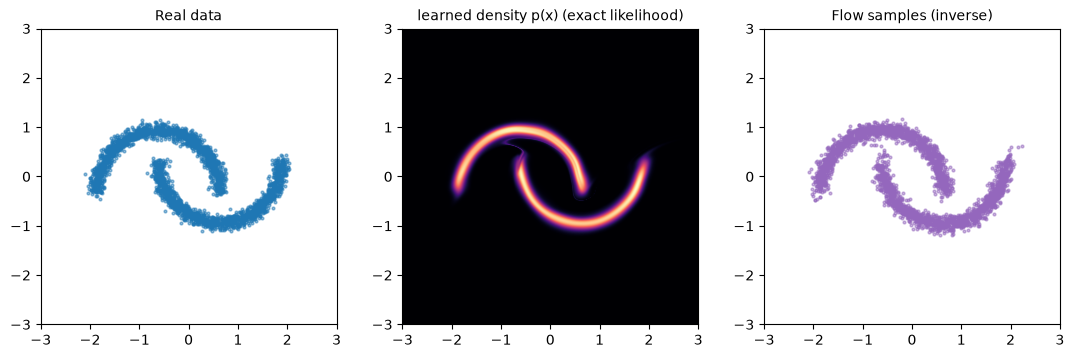

In [39]:
# ---------------- 정규화 흐름 최대 우도 학습 ----------------
set_seed(0)
flow = Flow(10).to(device)
opt = torch.optim.Adam(flow.parameters(), lr=3e-3)

t0 = time.time()
for step in range(1, 3001):
    x = sample_moons(512).to(device)
    loss = -flow_log_prob(flow, x).mean()          # 음의 로그 우도(NLL) 최소화
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 750 == 0:
        print(f'step {step:4d} | NLL {loss.item():.4f}')
print(f'학습 시간 {time.time()-t0:.1f}s')

g = torch.linspace(-3, 3, 300)
gx, gy = torch.meshgrid(g, g, indexing='ij')
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], 1).to(device)
with torch.no_grad():
    dens = flow_log_prob(flow, grid).exp().reshape(300, 300).cpu()
    x_gen = flow.inverse(torch.randn(3000, 2, device=device)).cpu()

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))
scatter2d(ax[0], sample_moons(3000), 'Real data')
ax[1].imshow(dens.T, origin='lower', extent=[-3, 3, -3, 3], cmap='magma')
ax[1].set_title('learned density p(x) (exact likelihood)', fontsize=10); ax[1].set_aspect('equal')
scatter2d(ax[2], x_gen, 'Flow samples (inverse)', color='C4')
plt.tight_layout(); plt.show()

---
# 문제 5. 자동 회귀 모델과 Autoregressive Diffusion (MNIST)

강의자료(그림 6-4): 확률 연쇄 규칙으로 결합 분포를 분해합니다.

$$\log p(x_{1:T})=\sum_{t=1}^{T}\log p(x_t\mid x_{<t})$$

**자동 회귀 확산 모델(ARDM, Autoregressive Diffusion Models)** 은 이를 확산 모델처럼 바꾼 것입니다.
고정된 순서(래스터 순서) 대신 **임의의 순서 $\sigma$** 로 픽셀을 하나씩 채우고, 다음 하한을 최적화합니다.

$$\log p(x)\ \ge\ D\cdot\mathbb{E}_{n\sim U\{0,\dots,D-1\}}\ \mathbb{E}_{\sigma}\left[\frac{1}{D-n}\sum_{k\notin \text{obs}}\log p(x_k\mid x_{\text{obs}})\right]$$

* $n$ = 이미 관측된 픽셀 수, `mask` = 관측 여부(1/0)
* 모델은 `[x*mask, mask]` 를 입력받아 **모든 픽셀의 베르누이 로지트**를 한 번에 출력합니다.
* 이 구조는 **흡수 상태(absorbing) 확산 모델**과 동치이며, 순서를 하나로 고정하면 평범한 자동 회귀 모델이 됩니다.

torchvision 사용 불가 -> sklearn digits 로 대체: No module named 'torchvision'
sklearn digits 8x8 | 데이터 (1797, 64) | 픽셀 차원 D = 64


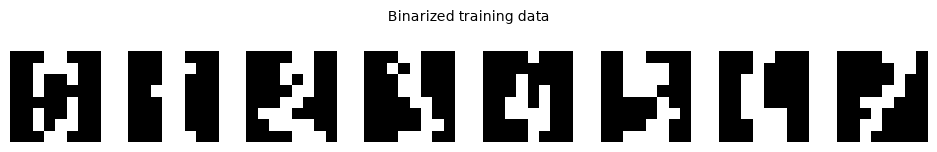

In [40]:
def load_image_data(size=14, n_max=6000):
    '''MNIST 를 size x size 로 축소해 반환. 실패 시 sklearn digits(8x8) 로 대체.'''
    try:
        from torchvision import datasets, transforms
        tf = transforms.Compose([transforms.Resize(size), transforms.ToTensor()])
        ds = datasets.MNIST(root='./data', train=True, download=True, transform=tf)
        n = min(n_max, len(ds))
        xs = torch.stack([ds[i][0] for i in range(n)])
        return xs, size, 'MNIST %dx%d' % (size, size)
    except Exception as e:
        print('torchvision 사용 불가 -> sklearn digits 로 대체:', e)
        from sklearn.datasets import load_digits
        d = load_digits()
        xs = torch.tensor(d.images / 16.0, dtype=torch.float32).unsqueeze(1)
        return xs, 8, 'sklearn digits 8x8'

IMGS, IMG_SIZE, DATA_NAME = load_image_data()
DIM = IMG_SIZE * IMG_SIZE
X_BIN = (IMGS > 0.5).float().view(-1, DIM)          # 이진화 (베르누이 모델링)
print(DATA_NAME, '| 데이터', tuple(X_BIN.shape), '| 픽셀 차원 D =', DIM)

def show_images(x, title='', n=8, size=None):
    size = size or IMG_SIZE
    x = x.detach().cpu().view(-1, size, size)[:n]
    fig, ax = plt.subplots(1, n, figsize=(1.2 * n, 1.5))
    for i in range(n):
        ax[i].imshow(x[i], cmap='gray'); ax[i].axis('off')
    fig.suptitle(title, fontsize=10); plt.tight_layout(); plt.show()

show_images(X_BIN, 'Binarized training data')

In [41]:
def chain_rule_logprob(cond_probs):
    '''확률 연쇄 규칙. cond_probs: (B,T) 각 원소가 p(x_t | x_<t). -> (B,) log p(x_1:T)'''
    logp = torch.log(cond_probs).sum(dim=1)
    return logp


class MaskedMLP(nn.Module):
    '''[x*mask, mask] -> 모든 픽셀의 베르누이 로지트'''
    def __init__(self, D, h=512):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(2 * D, h), nn.SiLU(),
                                 nn.Linear(h, h), nn.SiLU(), nn.Linear(h, D))
    def forward(self, x_masked, mask):
        return self.net(torch.cat([x_masked, mask], dim=1))


def ardm_loss(model, x):
    '''ARDM(순서 무관 자동 회귀) 손실 = 음의 로그 우도 하한'''
    B, D = x.shape
    n_obs = torch.randint(0, D, (B,), device=x.device)
    order = torch.rand(B, D, device=x.device).argsort(dim=1)
    mask = (order < n_obs[:, None]).float()
    logits = model(x * mask, mask)
    ll = -F.binary_cross_entropy_with_logits(logits, x, reduction='none')
    unobs = 1.0 - mask
    per_sample = D * (ll * unobs).sum(dim=1) / unobs.sum(dim=1).clamp_min(1.0)
    loss = -per_sample.mean()
    return loss


@torch.no_grad()
def ardm_sample(model, n, D, device):
    '''무작위 순서로 픽셀을 하나씩 채우는 자동 회귀 샘플링'''
    x = torch.zeros(n, D, device=device)
    mask = torch.zeros(n, D, device=device)
    order = torch.rand(n, D, device=device).argsort(dim=1)
    for i in range(D):
        idx = order[:, i:i + 1]
        logits = model(x * mask, mask)
        probs = torch.sigmoid(logits.gather(1, idx))
        values = torch.bernoulli(probs)
        x.scatter_(1, idx, values)
        mask.scatter_(1, idx, torch.ones_like(values))
    return x


In [42]:
# ---------------- 문제 5 채점 ----------------
cp = torch.tensor([[0.5, 0.25, 0.1], [0.9, 0.9, 0.9]])
expected = torch.tensor([math.log(0.5 * 0.25 * 0.1), math.log(0.9 ** 3)])
check('5-1 연쇄 규칙: 곱의 로그 == 로그의 합',
      torch.allclose(chain_rule_logprob(cp), expected, atol=1e-5))

class _UniformModel(nn.Module):
    def forward(self, xm, m): return torch.zeros_like(m)     # 항상 p=0.5
set_seed(5)
_l = ardm_loss(_UniformModel(), X_BIN[:4096])
check('5-2 ARDM 손실: 균등 모델이면 D*log2', abs(_l.item() - DIM * math.log(2)) < 0.6,
      f'기대 {DIM*math.log(2):.2f}, 실제 {_l.item():.2f} (D 배 가중치와 미관측 평균을 확인)')

_s = ardm_sample(_UniformModel(), 32, DIM, torch.device('cpu'))
check('5-3 샘플링: 이진 값만 출력', _s.shape == (32, DIM) and ((_s == 0) | (_s == 1)).all())
check('5-3 샘플링: 균등 모델이면 픽셀 평균 0.5', abs(_s.mean().item() - 0.5) < 0.05)

[PASS] 5-1 연쇄 규칙: 곱의 로그 == 로그의 합
[PASS] 5-2 ARDM 손실: 균등 모델이면 D*log2
[PASS] 5-3 샘플링: 이진 값만 출력
[PASS] 5-3 샘플링: 균등 모델이면 픽셀 평균 0.5


True

step  1000 | NLL 상한   18.35 nats  (0.414 bits/dim)
step  2000 | NLL 상한   17.39 nats  (0.392 bits/dim)
step  3000 | NLL 상한   15.62 nats  (0.352 bits/dim)
학습 시간 3.5s


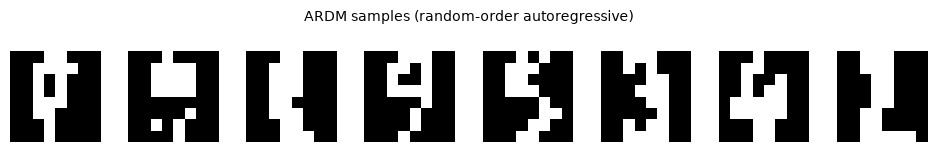

In [43]:
# ---------------- ARDM 학습 & 생성 ----------------
set_seed(0)
ardm = MaskedMLP(DIM).to(device)
opt = torch.optim.Adam(ardm.parameters(), lr=1e-3)
Xtr = X_BIN.to(device)

STEPS = 3000            # GPU 라면 10000 이상으로 늘리면 결과가 훨씬 좋아집니다
t0 = time.time()
for step in range(1, STEPS + 1):
    idx = torch.randint(0, Xtr.shape[0], (128,), device=device)
    loss = ardm_loss(ardm, Xtr[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 1000 == 0:
        print(f'step {step:5d} | NLL 상한 {loss.item():7.2f} nats  ({loss.item()/DIM/math.log(2):.3f} bits/dim)')
print(f'학습 시간 {time.time()-t0:.1f}s')

show_images(ardm_sample(ardm, 8, DIM, device), 'ARDM samples (random-order autoregressive)')

---
# 문제 6. 에너지 기반 모델(EBM)과 스코어

강의자료(그림 6-5): 에너지 기반 모델은 **레이블 없는 데이터로 학습하는 생성적 판별자**입니다.

$$p_\theta(x)=\frac{1}{Z_\theta}\exp\big(f_\theta(x)\big),\qquad Z_\theta=\int \exp(f_\theta(x))\,dx$$

$Z_\theta$ 는 계산할 수 없지만, **스코어**를 보면 정규화 상수가 사라집니다.

$$\nabla_x\log p_\theta(x)=\nabla_x f_\theta(x)-\underbrace{\nabla_x\log Z_\theta}_{=0}=\nabla_x f_\theta(x)$$

이것이 강의자료의 *"Should EBMs model the energy or the score?"* 가 묻는 지점이며, **확산 모델이 학습하는 것도 바로 이 스코어**입니다.

**랑주뱅 동역학** 으로 $p_\theta$ 에서 샘플링합니다.
$$x_{k+1}=x_k+\tfrac{\eta}{2}\nabla_x\log p_\theta(x_k)+\sqrt{\eta}\,z_k,\quad z_k\sim\mathcal{N}(0,I)$$

**대조 발산(Contrastive Divergence)** 손실:
$$L=-\Big(\mathbb{E}_{x\sim p_{data}}[f_\theta(x)]-\mathbb{E}_{x^-\sim p_\theta}[f_\theta(x^-)]\Big)$$
(그림 6-5의 "정답은 끌어올리고(pull up), 오답은 눌러내린다(push down)")

In [44]:
class EnergyNet(nn.Module):
    '''f_theta(x) 를 출력 (에너지의 음수). p(x) ∝ exp(f(x))'''
    def __init__(self, dim=2, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(dim, h), nn.SiLU(),
                                 nn.Linear(h, h), nn.SiLU(), nn.Linear(h, 1))
    def forward(self, x): return self.net(x).view(-1)


def score_from_f(f, x):
    '''스코어 = ∇_x log p(x) = ∇_x f(x) 를 autograd 로 계산'''
    x = x.detach().requires_grad_(True)
    grad = torch.autograd.grad(f(x).sum(), x, create_graph=False)[0]
    return grad.detach()


def langevin(f, x, n_steps=60, eta=0.02, noise_scale=1.0):
    '''랑주뱅 동역학으로 p(x) ∝ exp(f(x)) 에서 샘플링'''
    for _ in range(n_steps):
        s = score_from_f(f, x)
        x = x + (eta / 2) * s + noise_scale * math.sqrt(eta) * torch.randn_like(x)
    return x.detach()


def cd_loss(f, x_pos, x_neg, alpha=0.1):
    '''대조 발산 손실 (+ f 값이 발산하지 않도록 정규화 항)'''
    fp, fn = f(x_pos), f(x_neg)
    loss = -(fp.mean() - fn.mean())
    return loss + alpha * (fp ** 2 + fn ** 2).mean(), fp.mean().item(), fn.mean().item()


In [45]:
# ---------------- 문제 6 채점 ----------------
set_seed(6)
gauss_f = lambda x: -0.5 * (x ** 2).sum(dim=1)          # p(x) ∝ exp(-||x||^2/2) = N(0, I)
xt = torch.randn(1000, 2)
check('6-1 스코어: N(0,I) 의 스코어는 -x',
      torch.allclose(score_from_f(gauss_f, xt), -xt, atol=1e-5))

quad = lambda x: -0.5 * (((x - torch.tensor([1.0, -2.0])) ** 2) / torch.tensor([0.25, 4.0])).sum(dim=1)
xt2 = torch.randn(500, 2)
expected = -(xt2 - torch.tensor([1.0, -2.0])) / torch.tensor([0.25, 4.0])
check('6-1 스코어: 비등방 가우시안에서도 정확', torch.allclose(score_from_f(quad, xt2), expected, atol=1e-5))

# 알려진 분포에 랑주뱅을 돌려 실제로 그 분포가 나오는지 확인
set_seed(6)
xs = langevin(gauss_f, torch.randn(8000, 2) * 3.0, n_steps=800, eta=0.05)
check('6-2 랑주뱅: N(0,I) 로 수렴 (평균)', xs.mean().abs().max().item() < 0.08,
      f'평균 {xs.mean(0).tolist()}')
check('6-2 랑주뱅: N(0,I) 로 수렴 (표준편차)', abs(xs.std().item() - 1.0) < 0.08,
      f'표준편차 {xs.std().item():.4f} (계수 eta/2 와 sqrt(eta) 를 확인)')

f_dummy = EnergyNet()
l1, _, _ = cd_loss(f_dummy, torch.zeros(4, 2), torch.zeros(4, 2))
check('6-3 CD 손실: 양성/음성이 같으면 정규화 항만 남음', abs(l1.item() - 0.1 * 2 * f_dummy(torch.zeros(4, 2)).pow(2).mean().item()) < 1e-5)
lin_f = lambda x: x[:, 0]
l_good, _, _ = cd_loss(lin_f, torch.full((4, 2), 1.0), torch.full((4, 2), -1.0), alpha=0.0)
l_bad, _, _ = cd_loss(lin_f, torch.full((4, 2), -1.0), torch.full((4, 2), 1.0), alpha=0.0)
check('6-3 CD 손실: 데이터의 f 가 높을수록 손실이 작아짐', l_good.item() < l_bad.item())

[PASS] 6-1 스코어: N(0,I) 의 스코어는 -x
[PASS] 6-1 스코어: 비등방 가우시안에서도 정확
[PASS] 6-2 랑주뱅: N(0,I) 로 수렴 (평균)
[PASS] 6-2 랑주뱅: N(0,I) 로 수렴 (표준편차)
[PASS] 6-3 CD 손실: 양성/음성이 같으면 정규화 항만 남음
[PASS] 6-3 CD 손실: 데이터의 f 가 높을수록 손실이 작아짐


True

step  500 | loss  -0.724 | f(data)   0.726 | f(model)  -0.847
step 1000 | loss  -0.750 | f(data)   0.840 | f(model)  -0.673
step 1500 | loss  -0.957 | f(data)   1.139 | f(model)  -0.775
학습 시간 14.7s


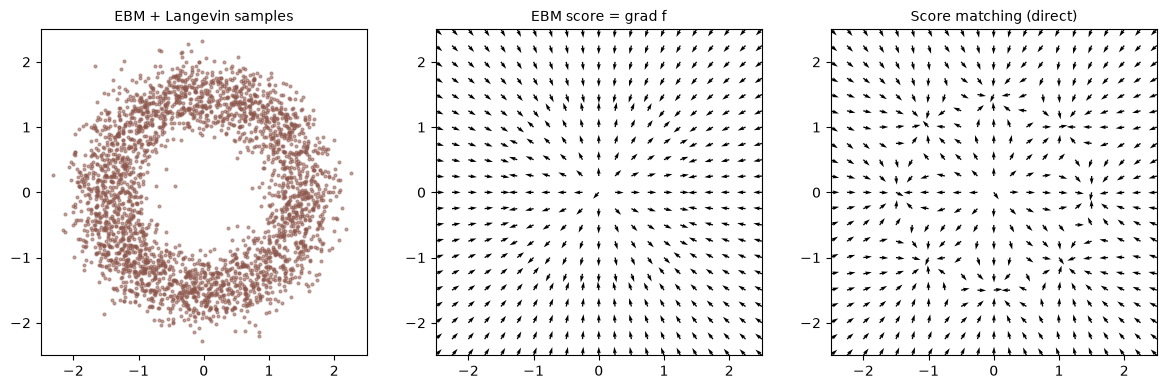

In [46]:
# ---------------- EBM 학습 (CD + 리플레이 버퍼) ----------------
set_seed(0)
f_net = EnergyNet().to(device)
opt = torch.optim.Adam(f_net.parameters(), lr=1e-3)
buffer = torch.randn(2048, 2, device=device)

t0 = time.time()
for step in range(1, 1501):
    x_pos = sample_8gaussians(256).to(device)
    bidx = torch.randint(0, buffer.shape[0], (256,), device=device)
    x_init = torch.where(torch.rand(256, 1, device=device) < 0.05,
                         torch.randn(256, 2, device=device), buffer[bidx])
    x_neg = langevin(f_net, x_init, n_steps=20, eta=0.05)
    buffer[bidx] = x_neg
    loss, fp, fn = cd_loss(f_net, x_pos, x_neg)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 500 == 0:
        print(f'step {step:4d} | loss {loss.item():7.3f} | f(data) {fp:7.3f} | f(model) {fn:7.3f}')
print(f'학습 시간 {time.time()-t0:.1f}s')

x_ebm = langevin(f_net, torch.randn(3000, 2, device=device), n_steps=400, eta=0.05).cpu()

# 비교군: 잡음 제거 스코어 매칭으로 스코어를 "직접" 학습 (확산 모델과 동일한 목적 함수)
set_seed(0)
s_net = nn.Sequential(nn.Linear(2, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 2)).to(device)
opt2 = torch.optim.Adam(s_net.parameters(), lr=2e-3)
SIG = 0.15
for step in range(1500):
    x = sample_8gaussians(512).to(device)
    n = torch.randn_like(x)
    xt = x + SIG * n
    # DSM 목표: s(x_t) ≈ -(x_t - x)/sigma^2 = -n/sigma
    loss2 = ((s_net(xt) + n / SIG) ** 2).sum(1).mean()
    opt2.zero_grad(); loss2.backward(); opt2.step()

# 두 방식이 만든 스코어 벡터장 비교
g = torch.linspace(-2.5, 2.5, 21)
gx, gy = torch.meshgrid(g, g, indexing='ij')
grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], 1).to(device)
sc_ebm = score_from_f(f_net, grid).cpu()
with torch.no_grad():
    sc_dsm = s_net(grid).cpu()
gridc = grid.cpu()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
scatter2d(ax[0], x_ebm, 'EBM + Langevin samples', color='C5', lim=2.5)
for a, sc, ttl in [(ax[1], sc_ebm, 'EBM score = grad f'), (ax[2], sc_dsm, 'Score matching (direct)')]:
    sc = sc / (sc.norm(dim=1, keepdim=True) + 1e-8)
    a.quiver(gridc[:, 0], gridc[:, 1], sc[:, 0], sc[:, 1], width=0.004)
    a.set_title(ttl, fontsize=10); a.set_aspect('equal'); a.set_xlim(-2.5, 2.5); a.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

### 생각해 보기 (문제 6)
* 두 벡터장 모두 데이터 모드를 향하지만, **EBM 은 스칼라 함수의 그래디언트라 보존장(conservative field)** 인 반면 스코어 네트워크는 그런 제약이 없습니다. 이것이 *Should EBMs model the energy or the score?* 의 논점입니다.
* *Learning Energy-Based Models by Diffusion Recovery Likelihood* 는 확산 역과정의 각 스텝마다 **조건부 EBM** $p_\theta(x_t|x_{t+1})$ 을 두어, 랑주뱅 샘플링이 훨씬 쉬운(국소적으로 매끄러운) 문제로 바뀌게 만듭니다.

---
# 문제 7. (종합) 이미지 DDPM 학습과 DDIM 결정론적 샘플링

문제 2의 2D DDPM 을 **이미지**로 확장합니다. 추가로 **DDIM** 샘플러를 구현합니다.

$$\hat{x}_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}},\qquad
x_{t-1}=\sqrt{\bar\alpha_{t-1}}\,\hat{x}_0+\sqrt{1-\bar\alpha_{t-1}}\,\epsilon_\theta(x_t,t)$$

DDIM 은 **잡음을 전혀 추가하지 않는 결정론적 사상**이므로, $x_T\mapsto x_0$ 가 가역 변환이 됩니다 → **문제 4의 정규화 흐름과 같은 성질**이고, 스텝을 건너뛸 수 있어 훨씬 빠릅니다.

> GPU 가 없다면 `STEPS_IMG` 를 그대로 두세요(약 2~4분). GPU 가 있다면 4000 이상으로 늘리면 숫자 모양이 훨씬 선명해집니다.

In [47]:
IMG_T = 200
betas_i  = torch.linspace(1e-4, 0.02, IMG_T, device=device)
alphas_i = 1.0 - betas_i
abar_i   = torch.cumprod(alphas_i, dim=0)

X_IMG = (IMGS.to(device) * 2.0 - 1.0)
print('이미지 텐서', tuple(X_IMG.shape))


def extract(arr, t, shape):
    '''arr[t] 를 (B,1,1,1) 형태로 브로드캐스팅 가능하게 꺼낸다.'''
    out = arr[t]
    return out.reshape(t.shape[0], *([1] * (len(shape) - 1)))


def q_sample_img(x0, t, noise):
    a = extract(abar_i, t, x0.shape)
    return a.sqrt() * x0 + (1.0 - a).sqrt() * noise


class TimeCondCNN(nn.Module):
    def __init__(self, ch=24, temb_dim=64):
        super().__init__()
        self.emb = SinusoidalEmb(temb_dim)
        self.tmlp = nn.Sequential(nn.Linear(temb_dim, 128), nn.SiLU(), nn.Linear(128, 4 * ch))
        self.c1 = nn.Conv2d(1, ch, 3, padding=1)
        self.c2 = nn.Conv2d(ch, ch, 3, padding=1)
        self.c3 = nn.Conv2d(ch, ch, 3, padding=1)
        self.c4 = nn.Conv2d(ch, ch, 3, padding=1)
        self.out = nn.Conv2d(ch, 1, 3, padding=1)
    def forward(self, x, t):
        e1, e2, e3, e4 = self.tmlp(self.emb(t)).chunk(4, dim=1)
        h = F.silu(self.c1(x) + e1[:, :, None, None])
        h = F.silu(self.c2(h) + e2[:, :, None, None])
        h = F.silu(self.c3(h) + e3[:, :, None, None]) + h
        h = F.silu(self.c4(h) + e4[:, :, None, None])
        return self.out(h)


def train_img_ddpm(model, X, steps=1200, bs=64, lr=2e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(1, steps + 1):
        idx = torch.randint(0, X.shape[0], (bs,), device=X.device)
        x0 = X[idx]
        t = torch.randint(0, IMG_T, (bs,), device=X.device)
        noise = torch.randn_like(x0)
        x_t = q_sample_img(x0, t, noise)
        loss = F.mse_loss(model(x_t, t), noise)
        opt.zero_grad(); loss.backward(); opt.step()
        if step % 400 == 0:
            print(f'  step {step:5d} | loss {loss.item():.4f}')
    return model


@torch.no_grad()
def ddim_sample(model, n, shape, n_steps=50, x_init=None):
    '''DDIM 샘플러 (잡음을 추가하지 않는 완전 결정론적 사상)'''
    ts = torch.linspace(IMG_T - 1, 0, n_steps).long().to(device)
    x = torch.randn(n, *shape, device=device) if x_init is None else x_init.clone()
    for i in range(n_steps):
        t = torch.full((n,), ts[i].item(), device=device, dtype=torch.long)
        a_t = extract(abar_i, t, x.shape)
        a_prev = extract(abar_i, torch.full_like(t, ts[i + 1].item()), x.shape) if i + 1 < n_steps \
                 else torch.ones_like(a_t)
        eps = model(x, t)
        x0_pred = ((x - torch.sqrt(1.0 - a_t) * eps) / torch.sqrt(a_t)).clamp(-1.0, 1.0)
        x = torch.sqrt(a_prev) * x0_pred + torch.sqrt(1.0 - a_prev) * eps
    return x


이미지 텐서 (1797, 1, 8, 8)


In [48]:
# ---------------- 문제 7 채점 ----------------
set_seed(7)
_t = torch.tensor([0, 5, 199], device=device)
_e = extract(abar_i, _t, (3, 1, 8, 8))
check('7-1 extract: 형태와 값', _e.shape == (3, 1, 1, 1) and
      torch.allclose(_e.view(-1), abar_i[_t]), '(B,1,1,1) 형태로 abar[t] 를 꺼내야 합니다.')

_n0 = min(2000, X_IMG.shape[0])
_x0 = X_IMG[:_n0]
_tt = torch.full((_n0,), 100, device=device, dtype=torch.long)
_xt = q_sample_img(_x0, _tt, torch.randn_like(_x0))
_res = _xt - abar_i[100].sqrt() * _x0
check('7-1 q_sample_img: 잔차 분산이 1-abar_t', abs(_res.var().item() - (1 - abar_i[100]).item()) < 0.03)

# 7-2: 학습 루프가 실제로 손실을 줄이는가 (같은 검증 배치로 학습 전/후 비교)
set_seed(77)
_m = TimeCondCNN().to(device)
_xv = X_IMG[:256]
_tv = torch.randint(0, IMG_T, (256,), device=device)
_nv = torch.randn_like(_xv)
_xtv = q_sample_img(_xv, _tv, _nv)
with torch.no_grad(): _before = F.mse_loss(_m(_xtv, _tv), _nv).item()
train_img_ddpm(_m, X_IMG[:1024], steps=200)
with torch.no_grad(): _after = F.mse_loss(_m(_xtv, _tv), _nv).item()
check('7-2 학습 루프가 손실을 실제로 줄임', _after < _before - 0.005,
      f'학습 전 {_before:.4f} -> 학습 후 {_after:.4f}')

# 7-3: 잡음 예측이 정확하면 DDIM 은 원본을 정확히 복원해야 한다
_x0t = torch.rand(4, 1, IMG_SIZE, IMG_SIZE, device=device) * 1.8 - 0.9
_nt = torch.randn_like(_x0t)
_xT = q_sample_img(_x0t, torch.full((4,), IMG_T - 1, device=device, dtype=torch.long), _nt)
class _OracleCNN(nn.Module):
    def forward(self, x, t): return _nt
_rec = ddim_sample(_OracleCNN(), 4, (1, IMG_SIZE, IMG_SIZE), n_steps=20, x_init=_xT)
check('7-3 DDIM: 잡음 예측이 정확하면 원본을 복원', (_rec - _x0t).abs().max().item() < 1e-3,
      f'최대 오차 {(_rec-_x0t).abs().max().item():.6f} (x0_pred 식과 재확산 식을 확인)')

class _ZeroCNN(nn.Module):
    def forward(self, x, t): return torch.zeros_like(x)
set_seed(7); a = ddim_sample(_ZeroCNN(), 4, (1, IMG_SIZE, IMG_SIZE), n_steps=20)
set_seed(7); b = ddim_sample(_ZeroCNN(), 4, (1, IMG_SIZE, IMG_SIZE), n_steps=20)
check('7-3 DDIM: 결정론적(같은 시드 -> 같은 결과)', torch.allclose(a, b, atol=1e-6))
check('7-3 DDIM: 출력 범위/유한성', torch.isfinite(a).all() and a.abs().max().item() <= 1.001)

[PASS] 7-1 extract: 형태와 값
[PASS] 7-1 q_sample_img: 잔차 분산이 1-abar_t
[PASS] 7-2 학습 루프가 손실을 실제로 줄임
[PASS] 7-3 DDIM: 잡음 예측이 정확하면 원본을 복원
[PASS] 7-3 DDIM: 결정론적(같은 시드 -> 같은 결과)
[PASS] 7-3 DDIM: 출력 범위/유한성


True

sklearn digits 8x8 에서 DDPM 학습 (5000 steps, device=cuda)
  step   400 | loss 0.2441
  step   800 | loss 0.2556
  step  1200 | loss 0.2131
  step  1600 | loss 0.2604
  step  2000 | loss 0.1852
  step  2400 | loss 0.2117
  step  2800 | loss 0.2101
  step  3200 | loss 0.1851
  step  3600 | loss 0.1856
  step  4000 | loss 0.1864
  step  4400 | loss 0.2145
  step  4800 | loss 0.1878
학습 시간 8.7s


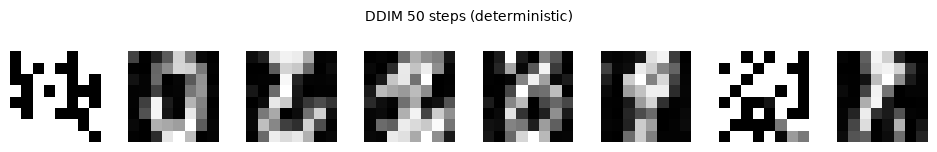

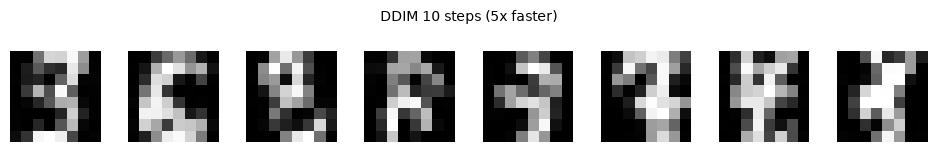

In [49]:
# ---------------- 이미지 DDPM 학습 & 샘플링 ----------------
STEPS_IMG = 1200 if device.type == 'cpu' else 5000
set_seed(0)
unet = TimeCondCNN().to(device)
print(f'{DATA_NAME} 에서 DDPM 학습 ({STEPS_IMG} steps, device={device})')
t0 = time.time()
train_img_ddpm(unet, X_IMG, steps=STEPS_IMG)
print(f'학습 시간 {time.time()-t0:.1f}s')

unet.eval()
show_images(((ddim_sample(unet, 8, (1, IMG_SIZE, IMG_SIZE), n_steps=50) + 1) / 2).clamp(0, 1),
            'DDIM 50 steps (deterministic)')
show_images(((ddim_sample(unet, 8, (1, IMG_SIZE, IMG_SIZE), n_steps=10) + 1) / 2).clamp(0, 1),
            'DDIM 10 steps (5x faster)')

---
# 마무리 — 그림 6-6의 5가지 패러다임 정리

| 생성 모델 | 확산 모델과의 결합 방식 | 이 노트북에서 | 대표 연구 |
|---|---|---|---|
| **변분 자동 인코더** | 확산 = 고정 인코더를 가진 **계층적 마르코프 VAE**. 잠재 공간에서 확산을 돌리기도 함(Latent Diffusion) | 문제 1 → 2 | Variational Diffusion Models |
| **생성적 적대 신경망** | 판별자 입력에 확산 잡음 주입 / 역과정 각 스텝을 조건부 GAN 으로 | 문제 3 | Diffusion-GAN, Denoising Diffusion GANs |
| **정규화 흐름** | 흐름으로 데이터를 변환한 뒤 확산, 또는 DDIM 처럼 결정론적 가역 사상 사용 | 문제 4 → 7 | Diffusion Normalizing Flow, INDM |
| **자동 회귀 모델** | 순서 무관 자동 회귀 = 흡수 상태 확산 | 문제 5 | Autoregressive Diffusion Models |
| **에너지 기반 모델** | 스코어 = $\nabla_x f_\theta(x)$, 확산 복구 우도로 조건부 EBM 학습 | 문제 6 | Diffusion Recovery Likelihood |

### 추가 과제 (선택)
1. 문제 2의 베타 스케줄을 **코사인 스케줄**로 바꾸고 샘플 품질을 비교해 보세요.
2. 문제 3의 `t_max` 를 10 / 60 / 150 으로 바꿔 가며 모드 커버리지를 비교해 보세요.
3. 문제 4의 흐름을 **8 Gaussians** 에 학습시키고, 흐름과 DDPM 중 어느 쪽이 모드 사이의 빈 공간에 확률을 덜 흘리는지 밀도 그림으로 비교해 보세요.
4. 문제 5에서 무작위 순서 대신 **래스터(왼→오, 위→아래) 고정 순서**만 쓰도록 바꾸면 NLL 과 샘플이 어떻게 달라지나요?
5. 문제 7에서 DDIM 을 **거꾸로**(x0 → xT) 돌려 이미지를 잠재 벡터로 인코딩하고, 두 이미지의 잠재 벡터를 보간(interpolation)해 보세요.

## 추가과제 코드

아래 셀들은 실행 시간이 길 수 있으므로 필요한 항목만 직접 실행하세요.


cosine step  500 | loss 0.4071
cosine step 1000 | loss 0.4488
cosine step 1500 | loss 0.4552
cosine step 2000 | loss 0.3775
코사인 schedule 최종 loss: 0.3775


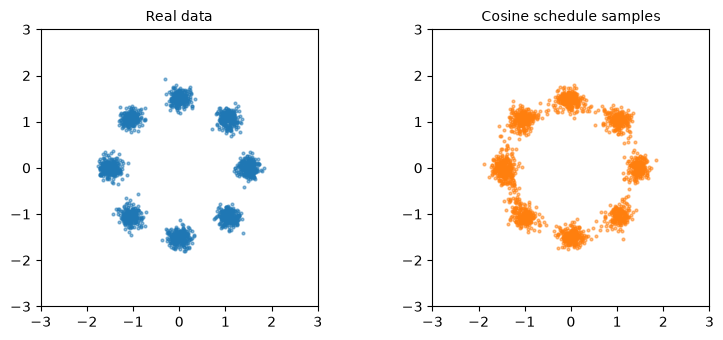

In [50]:
# ==================== 추가과제 1 ====================
# 코사인 beta schedule DDPM을 학습하고 선형 schedule과 샘플을 비교합니다.

EXTRA1_STEPS = 2000


def cosine_beta_schedule_extra(timesteps, s=0.008, device=device):
    steps = torch.linspace(0, timesteps, timesteps + 1, device=device)
    alpha_bar = torch.cos(((steps / timesteps) + s) / (1 + s) * math.pi / 2).square()
    alpha_bar = alpha_bar / alpha_bar[0]
    return (1.0 - alpha_bar[1:] / alpha_bar[:-1]).clamp(0.0, 0.999)


def train_2d_schedule_extra(schedule_betas, steps=EXTRA1_STEPS, batch_size=512):
    schedule_alphas = 1.0 - schedule_betas
    schedule_abar = torch.cumprod(schedule_alphas, dim=0)
    schedule_model = EpsMLP().to(device)
    schedule_optimizer = torch.optim.Adam(schedule_model.parameters(), lr=2e-3)
    schedule_history = []
    for step in range(steps):
        batch = sample_8gaussians(batch_size).to(device)
        loss = ddpm_loss(schedule_model, batch, len(schedule_betas), schedule_abar)
        schedule_optimizer.zero_grad()
        loss.backward()
        schedule_optimizer.step()
        schedule_history.append(loss.item())
        if (step + 1) % 500 == 0:
            print(f'cosine step {step + 1:4d} | loss {loss.item():.4f}')
    return schedule_model, schedule_betas, schedule_alphas, schedule_abar, schedule_history

cosine_betas_extra = cosine_beta_schedule_extra(T)
cosine_model_extra, cosine_betas_extra, cosine_alphas_extra, cosine_abar_extra, cosine_history_extra = \
    train_2d_schedule_extra(cosine_betas_extra)
cosine_samples_extra = p_sample_loop(
    cosine_model_extra, 2000, len(cosine_betas_extra),
    cosine_betas_extra, cosine_alphas_extra, cosine_abar_extra)

print(f'코사인 schedule 최종 loss: {cosine_history_extra[-1]:.4f}')
fig, ax = plt.subplots(1, 2, figsize=(8, 3.5))
scatter2d(ax[0], sample_8gaussians(2000), 'Real data')
scatter2d(ax[1], cosine_samples_extra.cpu(), 'Cosine schedule samples', color='C1')
plt.tight_layout(); plt.show()


t_max=10: 8/8 modes, counts=[197, 164, 252, 251, 262, 268, 270, 238]
t_max=60: 8/8 modes, counts=[212, 214, 217, 236, 240, 199, 240, 238]
t_max=150: 8/8 modes, counts=[180, 204, 186, 203, 209, 177, 241, 192]


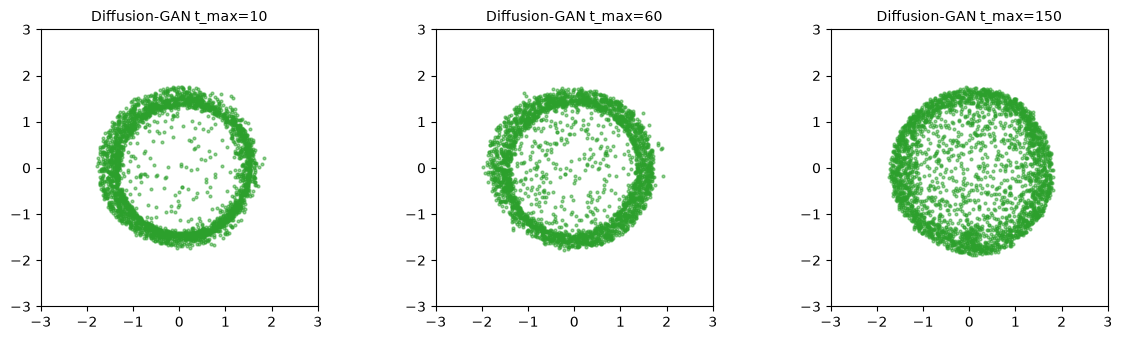

In [51]:
# ==================== 추가과제 2 ====================
# Diffusion-GAN의 t_max=10, 60, 150에서 모드 커버리지를 비교합니다.

EXTRA2_STEPS = 3000
extra2_results = {}

for extra2_tmax in (10, 60, 150):
    extra2_samples, extra2_d_loss, extra2_g_loss = train_gan(
        use_diffusion=True,
        steps=EXTRA2_STEPS,
        t_max=extra2_tmax,
        seed=extra2_tmax,
    )
    extra2_modes, extra2_counts = mode_coverage(extra2_samples)
    extra2_results[extra2_tmax] = extra2_samples
    print(f't_max={extra2_tmax}: {extra2_modes}/8 modes, counts={extra2_counts}')

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
for extra2_axis, extra2_tmax in zip(ax, (10, 60, 150)):
    scatter2d(
        extra2_axis,
        extra2_results[extra2_tmax],
        f'Diffusion-GAN t_max={extra2_tmax}',
        color='C2',
    )
plt.tight_layout(); plt.show()


flow step  750 | NLL 1.3196
flow step 1500 | NLL 1.1883
flow step 2250 | NLL 1.2862
flow step 3000 | NLL 1.0252


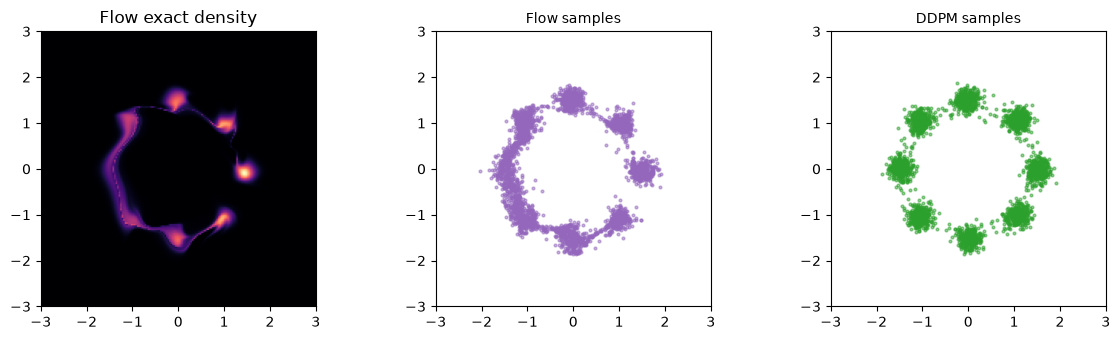

In [52]:
# ==================== 추가과제 3 ====================
# 8 Gaussians에 Normalizing Flow를 학습하고 DDPM 샘플과 비교합니다.

EXTRA3_STEPS = 3000
extra3_flow = Flow(10).to(device)
extra3_optimizer = torch.optim.Adam(extra3_flow.parameters(), lr=3e-3)
extra3_history = []

for extra3_step in range(EXTRA3_STEPS):
    extra3_batch = sample_8gaussians(512).to(device)
    extra3_loss = -flow_log_prob(extra3_flow, extra3_batch).mean()
    extra3_optimizer.zero_grad()
    extra3_loss.backward()
    extra3_optimizer.step()
    extra3_history.append(extra3_loss.item())
    if (extra3_step + 1) % 750 == 0:
        print(f'flow step {extra3_step + 1:4d} | NLL {extra3_loss.item():.4f}')

with torch.no_grad():
    extra3_flow_samples = extra3_flow.inverse(torch.randn(3000, 2, device=device)).cpu()

# 문제 2의 DDPM 학습 셀을 먼저 실행했다면 eps_model을 그대로 비교에 사용합니다.
extra3_ddpm_samples = p_sample_loop(eps_model, 3000, T, betas, alphas, abar).cpu()

extra3_axis = torch.linspace(-3, 3, 180, device=device)
extra3_gx, extra3_gy = torch.meshgrid(extra3_axis, extra3_axis, indexing='ij')
extra3_grid = torch.stack([extra3_gx.reshape(-1), extra3_gy.reshape(-1)], dim=1)
with torch.no_grad():
    extra3_density = flow_log_prob(extra3_flow, extra3_grid).exp().reshape(180, 180).cpu()

fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))
ax[0].imshow(extra3_density.T, origin='lower', extent=(-3, 3, -3, 3), cmap='magma')
ax[0].set_title('Flow exact density')
scatter2d(ax[1], extra3_flow_samples, 'Flow samples', color='C4')
scatter2d(ax[2], extra3_ddpm_samples, 'DDPM samples', color='C2')
plt.tight_layout(); plt.show()


raster ARDM step 1000 | NLL 15.967
raster ARDM step 2000 | NLL 16.302
raster ARDM step 3000 | NLL 15.052


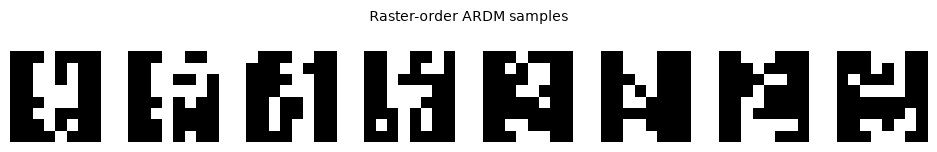

raster ARDM final NLL: 15.052


In [53]:
# ==================== 추가과제 4 ====================
# 무작위 순서 ARDM과 래스터(왼쪽->오른쪽, 위->아래) 순서를 비교합니다.

def raster_ardm_loss(model, x):
    extra4_batch, extra4_dim = x.shape
    extra4_n_obs = torch.randint(0, extra4_dim, (extra4_batch,), device=x.device)
    extra4_order = torch.arange(extra4_dim, device=x.device).expand(extra4_batch, -1)
    extra4_mask = (extra4_order < extra4_n_obs[:, None]).float()
    extra4_logits = model(x * extra4_mask, extra4_mask)
    extra4_ll = -F.binary_cross_entropy_with_logits(
        extra4_logits, x, reduction='none')
    extra4_unobserved = 1.0 - extra4_mask
    extra4_per_sample = extra4_dim * (extra4_ll * extra4_unobserved).sum(dim=1)
    extra4_per_sample = extra4_per_sample / extra4_unobserved.sum(dim=1).clamp_min(1.0)
    return -extra4_per_sample.mean()

extra4_steps = 3000
extra4_model = MaskedMLP(DIM).to(device)
extra4_optimizer = torch.optim.Adam(extra4_model.parameters(), lr=1e-3)
extra4_history = []
extra4_xtrain = X_BIN.to(device)

for extra4_step in range(extra4_steps):
    extra4_indices = torch.randint(0, extra4_xtrain.shape[0], (128,), device=device)
    extra4_loss = raster_ardm_loss(extra4_model, extra4_xtrain[extra4_indices])
    extra4_optimizer.zero_grad()
    extra4_loss.backward()
    extra4_optimizer.step()
    extra4_history.append(extra4_loss.item())
    if (extra4_step + 1) % 1000 == 0:
        print(f'raster ARDM step {extra4_step + 1:4d} | NLL {extra4_loss.item():.3f}')

extra4_samples = ardm_sample(extra4_model, 8, DIM, device)
show_images(extra4_samples, 'Raster-order ARDM samples')
print(f'raster ARDM final NLL: {extra4_history[-1]:.3f}')


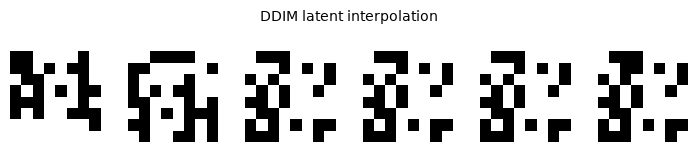

In [54]:
# ==================== 추가과제 5 ====================
# DDIM 역과정으로 x0 -> xT 인코딩 후 두 이미지의 잠재 벡터를 보간합니다.

@torch.no_grad()
def ddim_encode_extra(model, x0, n_steps=50):
    extra5_ts = torch.linspace(0, IMG_T - 1, n_steps).long().to(device)
    extra5_x = x0.clone()
    for extra5_index in range(n_steps - 1):
        extra5_t = torch.full(
            (extra5_x.shape[0],), extra5_ts[extra5_index].item(),
            device=device, dtype=torch.long)
        extra5_next_t = torch.full(
            (extra5_x.shape[0],), extra5_ts[extra5_index + 1].item(),
            device=device, dtype=torch.long)
        extra5_a_t = extract(abar_i, extra5_t, extra5_x.shape)
        extra5_a_next = extract(abar_i, extra5_next_t, extra5_x.shape)
        extra5_eps = model(extra5_x, extra5_t)
        extra5_x0_pred = (
            (extra5_x - torch.sqrt(1.0 - extra5_a_t) * extra5_eps)
            / torch.sqrt(extra5_a_t)
        ).clamp(-1.0, 1.0)
        extra5_x = (
            torch.sqrt(extra5_a_next) * extra5_x0_pred
            + torch.sqrt(1.0 - extra5_a_next) * extra5_eps
        )
    return extra5_x


@torch.no_grad()
def ddim_interpolate_extra(model, image_a, image_b, n_steps=50, n_points=6):
    extra5_latent_a = ddim_encode_extra(model, image_a.to(device), n_steps)
    extra5_latent_b = ddim_encode_extra(model, image_b.to(device), n_steps)
    extra5_weights = torch.linspace(0.0, 1.0, n_points, device=device)
    extra5_latents = []
    for extra5_weight in extra5_weights:
        extra5_latents.append(
            (1.0 - extra5_weight) * extra5_latent_a[:1]
            + extra5_weight * extra5_latent_b[:1]
        )
    extra5_decoded = [
        ddim_sample(model, 1, tuple(image_a.shape[1:]), n_steps, x_init=latent)
        for latent in extra5_latents
    ]
    return torch.cat(extra5_decoded, dim=0), extra5_latent_a, extra5_latent_b

# 이미지 DDPM 학습 셀을 먼저 실행한 뒤 이 셀을 실행하세요.
extra5_pair = X_IMG[:2]
extra5_interpolated, extra5_latent_a, extra5_latent_b = ddim_interpolate_extra(
    unet, extra5_pair[:1], extra5_pair[1:2], n_steps=50, n_points=6)
show_images(
    ((extra5_interpolated + 1.0) / 2.0).clamp(0.0, 1.0),
    'DDIM latent interpolation',
    n=6,
)


In [55]:
report()

채점 결과: 41 / 41 통과
  O  1-1 재매개변수화: 표준정규 통계량
  O  1-1 재매개변수화: 평균/표준편차 반영
  O  1-1 미분 가능(그래디언트 흐름)
  O  1-2 KL: 표준정규이면 0
  O  1-2 KL: 몬테카를로 추정치와 일치
  O  1-3 -ELBO 값이 이론값과 일치
  O  1-3 -ELBO: 실제 모델에서도 유한/양수
  O  2-1 q_sample t=0: 평균/분산
  O  2-1 q_sample t=50: 평균/분산
  O  2-1 q_sample t=199: 평균/분산
  O  2-2 손실: 0을 출력하는 모델이면 E||eps||^2 = 1
  O  2-3 샘플러: 출력 형태/유한성
  O  2-3 샘플러: 역방향 사슬의 분산이 이론값과 일치
  O  3-1 D 손실: 로지트가 모두 0이면 2*log2
  O  3-1 D 손실: 완벽한 판별자면 0에 가까움
  O  3-1 D 손실: 실수한 판별자면 커짐
  O  3-2 G 손실: 로지트 0이면 log2
  O  3-2 G 손실: 단조 감소(가짜를 진짜로 속일수록 작아짐)
  O  3-3 확산 잡음 주입: 잡음이 실제로 섞임
  O  3-3 확산 잡음 주입: 분산이 N(0,I) 쪽으로 수축
  O  3-3 t_max=1 이면 거의 원본 (t=0)
  O  4-1/4-2 가역성: inverse(forward(x)) == x
  O  4-1 로그 야코비안이 0이 아님(항등 변환이 아님)
  O  4-1 로그 야코비안 행렬식이 autograd 결과와 일치
  O  4-3 로그 우도: 밀도의 적분 == 1
  O  5-1 연쇄 규칙: 곱의 로그 == 로그의 합
  O  5-2 ARDM 손실: 균등 모델이면 D*log2
  O  5-3 샘플링: 이진 값만 출력
  O  5-3 샘플링: 균등 모델이면 픽셀 평균 0.5
  O  6-1 스코어: N(0,I) 의 스코어는 -x
  O  6-1 스코어: 비등방 가우시안에서도 정확
  O  6-2 랑주뱅: N(0,I) 로 수렴 (